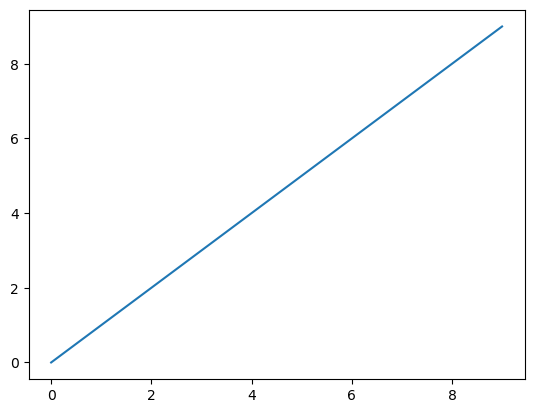

In [2]:
#package imports
#If using Jupyter locally, make sure you have pip installed saphires and any dependencies you need.
import saphires as saph
import matplotlib
import matplotlib.pyplot as plt
#matplotlib.use('Qt5Agg')
%matplotlib inline

import numpy as np
import os
from scipy.optimize import curve_fit

import pickle as pkl
from scipy.ndimage import gaussian_filter
import astropy



x = [0,1,2,3,4,5,6,7,8,9]
y = x
plt.plot(x, y)    #Testing out matplotlib inline to make sure this runs
print()
plt.show()

In [3]:
import os, glob
import numpy as np
from astropy.time import Time

star = 'V457Vir'


folder = os.path.join(r"C:\Users\Jonah\Astro\Stars\DATA\stars", star)

# 1) find all .p files whose basename starts with the same first letter as `star`
txtfiles = sorted(
    os.path.basename(f)
    for f in glob.glob(os.path.join(folder, "*.p"))
    if os.path.basename(f)[0].lower() == star[0].lower()
)

# 2) load the .dat into a true 2-D object array
dat_path  = os.path.join(folder, f"{star}_coude_head.dat")
#dat_path  = os.path.join(folder, f"{star}_nres_head.dat")
stardata  = np.genfromtxt(dat_path, delimiter=",", dtype=object)

# 3) slice out cols 5 and 6 and convert to float
BJD       = stardata[:, 5].astype(float)
BVCORR    = stardata[:, 6].astype(float)



# OPTIONAL: remove one entry (file + BJD + BVCORR)
#idx_to_remove = -1  # zero-based index of the row you want to drop
#txtfiles.pop(idx_to_remove)
#BJD    = np.delete(BJD,    idx_to_remove)
#BVCORR = np.delete(BVCORR, idx_to_remove)






# 4) convert BJD (TDB) → UTC ISO strings via Astropy
times = Time(BJD, format='jd', scale='tdb')
dates = times.utc.iso  # array of "YYYY-MM-DD HH:MM:SS.sss" strings in UTC

# string/table format for print check
header_fmt = "{:>3}  {:^32}  {:^25}    {:^12}    {:^16}"
row_fmt    = "{:>3}  {:<32}  {:<25}    {:>12}    {:>10}"

# 5) print header
print(header_fmt.format("Idx", "Filename", "Date (UTC)", "BJD", "BVCORR"))
print("-" * 100)

# 6) print each row
for i, (fn, date, bjd, bv) in enumerate(zip(txtfiles, dates, BJD, BVCORR), start=1):
    # truncate milliseconds to three decimal places:
    date_str = date  # already "YYYY-MM-DD HH:MM:SS.sss"
    print(row_fmt.format(i, fn, date_str, f"{bjd:.6f}", f"{bv:.3f}"))


path = os.path.join(folder, "")
print(f"\n{path}")

Idx              Filename                     Date (UTC)                BJD              BVCORR     
----------------------------------------------------------------------------------------------------
  1  V457Vir_2020-05-11_0_5200_4.5.p   2020-05-11 05:41:58.406      2458980.738282       -16.979
  2  V457Vir_2021-01-31_0_5200_4.5.p   2021-01-31 10:42:31.551      2459245.946999        25.993
  3  V457Vir_2021-03-30_0_5200_4.5.p   2021-03-30 05:41:12.099      2459303.737746         2.744
  4  V457Vir_2021-04-01_0_5200_4.5.p   2021-04-01 06:53:19.474      2459305.787832         1.605
  5  V457Vir_2021-04-23_0_5200_4.5.p   2021-04-23 04:36:15.513      2459327.692647        -8.938
  6  V457Vir_2021-05-04_0_5200_4.5.p   2021-05-04 06:06:04.203      2459338.755016       -14.046

C:\Users\Jonah\Astro\Stars\DATA\stars\V457Vir\


In [4]:
#Constants
R_coude = 60000.0     #spectral resolution of the Coude.
c = (2.9979245*10**5)



In [5]:
BJD, BVCORR

(array([2458980.73828231, 2459245.94699926, 2459303.73774636,
        2459305.78783171, 2459327.69264698, 2459338.75501607]),
 array([-16.979,  25.993,   2.744,   1.605,  -8.938, -14.046]))

In [7]:
Force_SB1 = True      #Force SB1 fit  (if asymmetry is impacting fit profile)
manual = False        #Force manual guessing, uses "guesses" array for p0 instead of automated guesses


guesses = [                                #force guess format, can take p0 prints from runs and edit
[0.016, 9.681, 20.099, 0.0],
[0.016, -5, 30, 0.012, 65, 25, 0.0],
[0.016, 34.231, 30, 0.012, 100, 25., 0.0],
[0.016, 37.052, 30, 0.012, 95, 25, 0.0]
]


from pathlib import Path

outdir = Path("starBFs") / star
outdir.mkdir(parents=True, exist_ok=True)

File 1
C:\Users\Jonah\Astro\Stars\DATA\stars\V457Vir\V457Vir_2020-05-11_0_5200_4.5.p
Number of Spectral Orders: 34
BJD: 2458980.7382823075
BVCORR -16.979
  Peak 1: center = -16.92 km/s, width = 40.70 km/s
  Peak 2: center = 40.10 km/s, width = 11.00 km/s


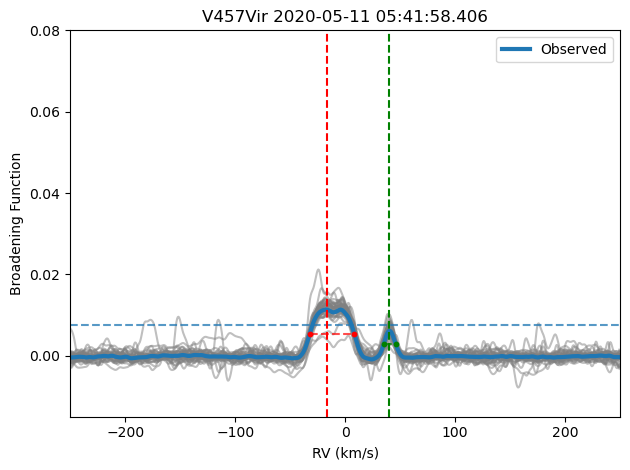

SB1
Amps: [0.01134513 0.00612594]
Centers: [-16.91516763  40.09521215]
Widths: [40.70105278 10.99709838]
p0: [0.012, -18.607, 22.386, 0.0]

Vsini p0: [0.01247964043132113, -12.007541253547927, 22.385579029842486, 0.0]
  BVCORR: -16.979 km/s

      Results
  Primary RV (uncorrected): -12.01 + 0.22 - 0.18
  Primary RV (Barycenter Corrected): -28.99 + 0.22 - 0.18

  Primary vsini: 26.07 +/- 0.3 km/s
  
[(-28.985861196251808, 0.22243597924392766, 0.18193986875251333, 26.069624449686067, 0.2969586527552161, nan, nan, nan, nan, nan)]


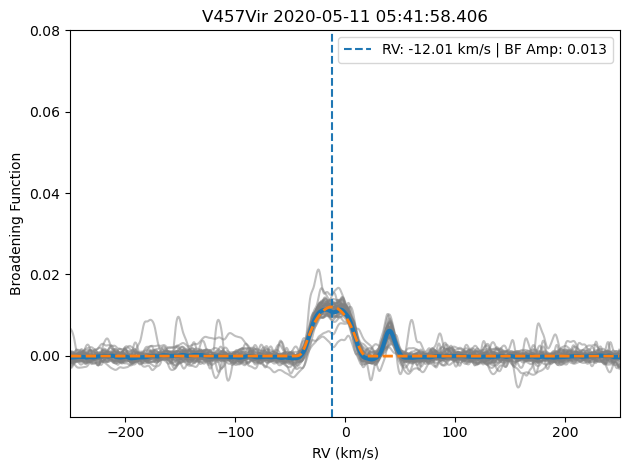


File 2
C:\Users\Jonah\Astro\Stars\DATA\stars\V457Vir\V457Vir_2021-01-31_0_5200_4.5.p
Number of Spectral Orders: 34
BJD: 2459245.9469992565
BVCORR 25.993
  Peak 1: center = 3.76 km/s, width = 41.39 km/s
  Peak 2: center = -13.16 km/s, width = 8.64 km/s


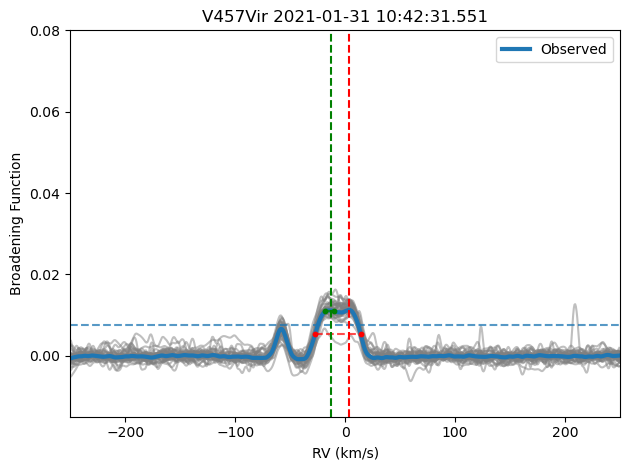

SB1
Amps: [0.01124768 0.011127  ]
Centers: [  3.75892649 -13.15624271]
Widths: [41.38657789  8.64493817]
p0: [0.012, 4.135, 22.763, 0.0]

Vsini p0: [0.012372448681778137, -6.578351649985102, 22.762617841654148, 0.0]
  BVCORR: 25.993 km/s

      Results
  Primary RV (uncorrected): -6.58 + 0.15 - 0.15
  Primary RV (Barycenter Corrected): 19.41 + 0.15 - 0.15

  Primary vsini: 26.45 +/- 0.33 km/s
  
[(19.414077985102644, 0.15149052607316627, 0.1475158360929285, 26.447567311669548, 0.33345273847933377, nan, nan, nan, nan, nan)]


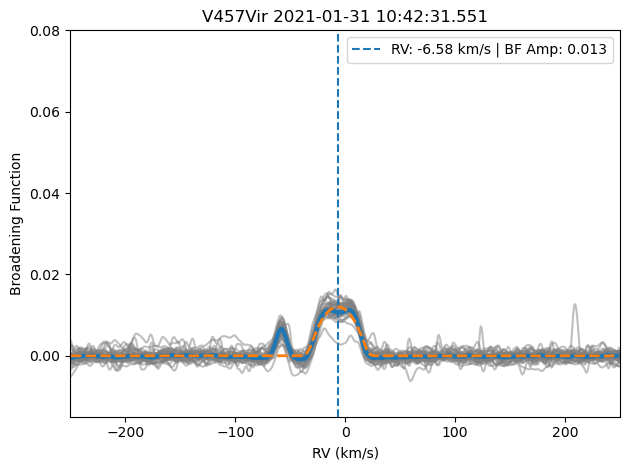


File 3
C:\Users\Jonah\Astro\Stars\DATA\stars\V457Vir\V457Vir_2021-03-30_0_5200_4.5.p
Number of Spectral Orders: 34
BJD: 2459303.737746355
BVCORR 2.744
  Peak 1: center = 24.43 km/s, width = 40.61 km/s
  Peak 2: center = 5.01 km/s, width = 1.92 km/s


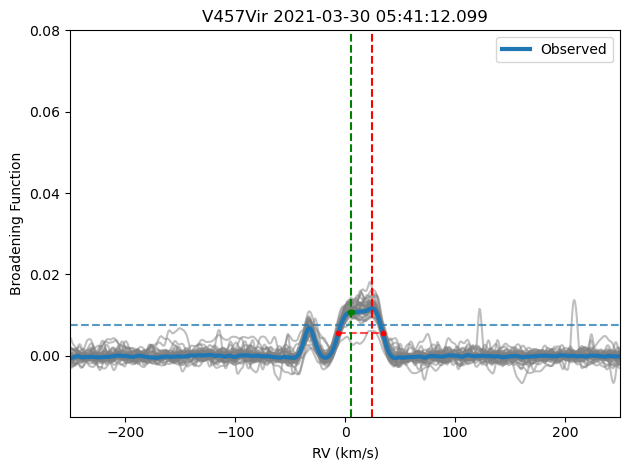

SB1
Amps: [0.01166219 0.010705  ]
Centers: [24.43305532  5.01190878]
Widths: [40.60989695  1.91694166]
p0: [0.013, 26.876, 22.335, 0.0]

Vsini p0: [0.012828407935475215, 14.248738753355013, 22.335443324163382, 0.0]
  BVCORR: 2.744 km/s

      Results
  Primary RV (uncorrected): 14.25 + 0.13 - 0.13
  Primary RV (Barycenter Corrected): 16.99 + 0.13 - 0.13

  Primary vsini: 26.17 +/- 0.34 km/s
  
[(16.99286917204681, 0.13279776404396593, 0.13267997491879946, 26.171337727650336, 0.3380755965612334, nan, nan, nan, nan, nan)]


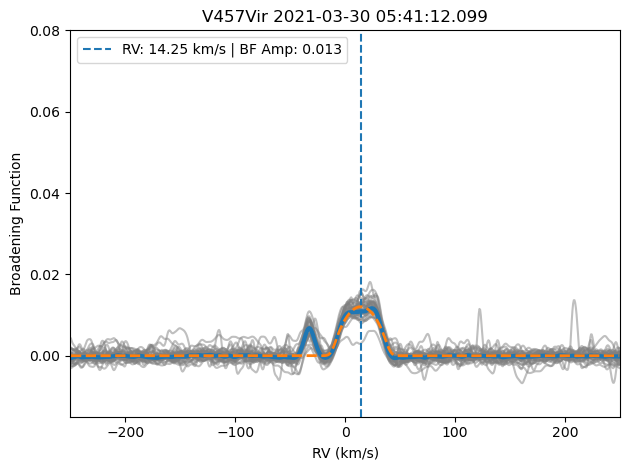


File 4
C:\Users\Jonah\Astro\Stars\DATA\stars\V457Vir\V457Vir_2021-04-01_0_5200_4.5.p
Number of Spectral Orders: 34
BJD: 2459305.7878317116
BVCORR 1.605
  Peak 1: center = 35.08 km/s, width = 41.73 km/s
  Peak 2: center = 52.63 km/s, width = 4.52 km/s


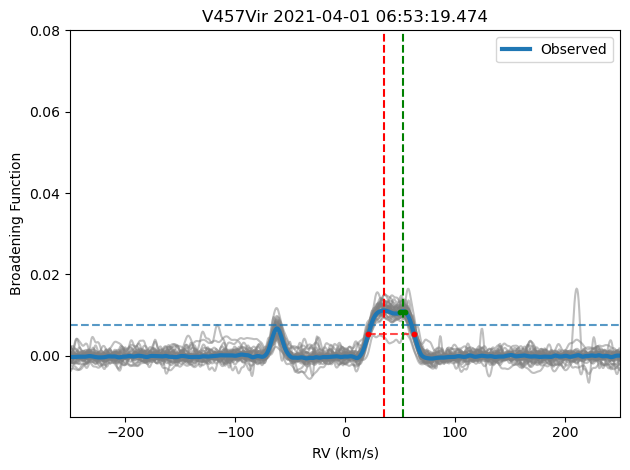

SB1
Amps: [0.01112652 0.01100089]
Centers: [35.0834195  52.62512925]
Widths: [41.72975852  4.52281986]
p0: [0.012, 38.592, 22.951, 0.0]

Vsini p0: [0.01223916990957353, 41.79430707259872, 22.95136718344388, 0.0]
  BVCORR: 1.605 km/s

      Results
  Primary RV (uncorrected): 41.79 + 0.2 - 0.17
  Primary RV (Barycenter Corrected): 43.4 + 0.2 - 0.17

  Primary vsini: 26.66 +/- 0.33 km/s
  
[(43.39953082694227, 0.2019747233835858, 0.16587483459282026, 26.659121408077873, 0.33385704360967383, nan, nan, nan, nan, nan)]


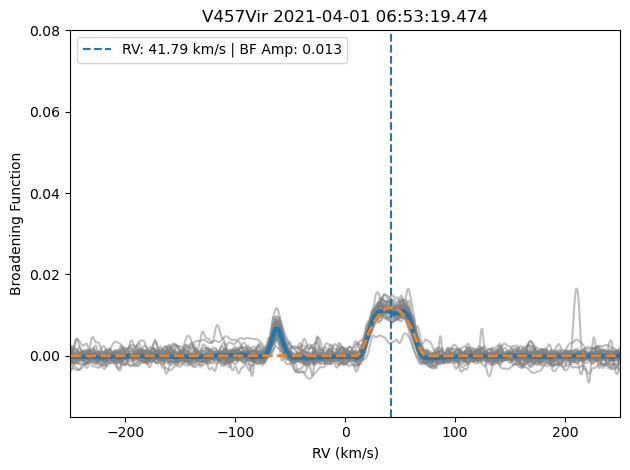


File 5
C:\Users\Jonah\Astro\Stars\DATA\stars\V457Vir\V457Vir_2021-04-23_0_5200_4.5.p
Number of Spectral Orders: 34
BJD: 2459327.6926469756
BVCORR -8.938
  Peak 1: center = -17.54 km/s, width = 40.87 km/s
  Peak 2: center = 23.81 km/s, width = 9.47 km/s


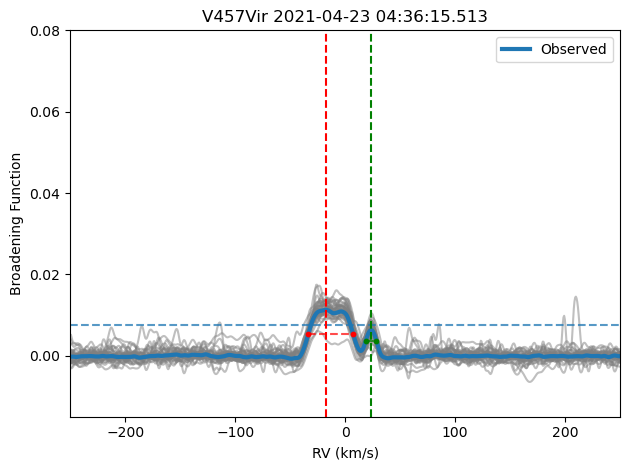

SB1
Amps: [0.01125837 0.0062905 ]
Centers: [-17.54166125  23.80654027]
Widths: [40.87214988  9.46602789]
p0: [0.012, -19.296, 22.48, 0.0]

Vsini p0: [0.012384212380494388, -11.585400899969708, 22.479682432127813, 0.0]
  BVCORR: -8.938 km/s

      Results
  Primary RV (uncorrected): -11.59 + 0.28 - 0.25
  Primary RV (Barycenter Corrected): -20.52 + 0.28 - 0.25

  Primary vsini: 26.56 +/- 0.33 km/s
  
[(-20.523055493295043, 0.28004185658192604, 0.24944127769580327, 26.55706829442371, 0.3269354697634266, nan, nan, nan, nan, nan)]


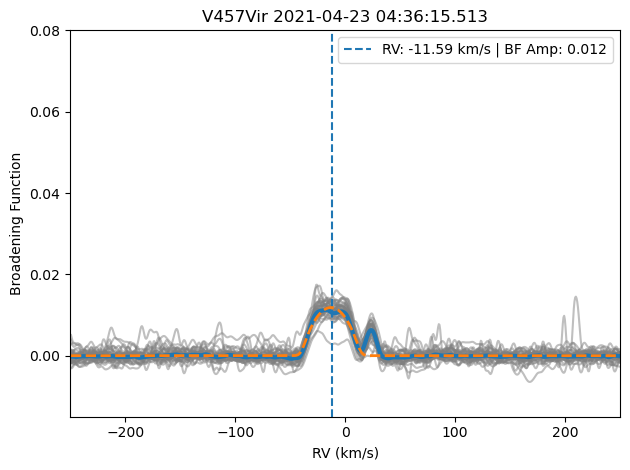


File 6
C:\Users\Jonah\Astro\Stars\DATA\stars\V457Vir\V457Vir_2021-05-04_0_5200_4.5.p
Number of Spectral Orders: 34
BJD: 2459338.7550160694
BVCORR -14.046
  Peak 1: center = -31.95 km/s, width = 40.92 km/s
  Peak 2: center = -53.88 km/s, width = 1.80 km/s


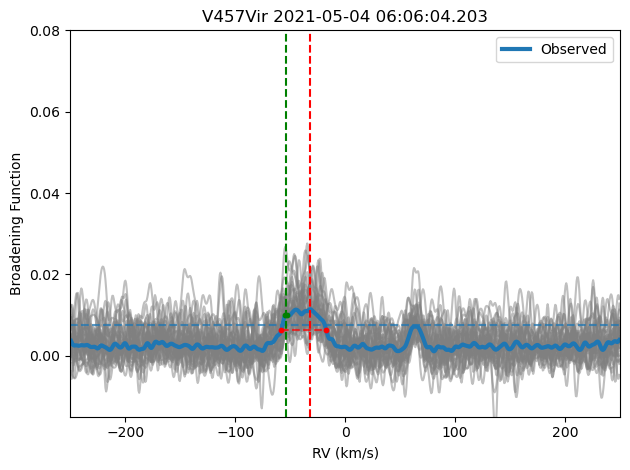

SB1
Amps: [0.01142971 0.01006251]
Centers: [-31.95098427 -53.87813033]
Widths: [40.92106775  1.79848323]
p0: [0.013, -35.146, 22.507, 0.0]

Vsini p0: [0.012572675679927878, -38.25258287501347, 22.50658726358458, 0.0]
  BVCORR: -14.046 km/s

      Results
  Primary RV (uncorrected): -38.25 + 0.38 - 0.45
  Primary RV (Barycenter Corrected): -52.3 + 0.38 - 0.45

  Primary vsini: 26.97 +/- 0.38 km/s
  
[(-52.29679064916168, 0.38210462358097175, 0.4482981122067997, 26.966368310386827, 0.3817360979730225, nan, nan, nan, nan, nan)]


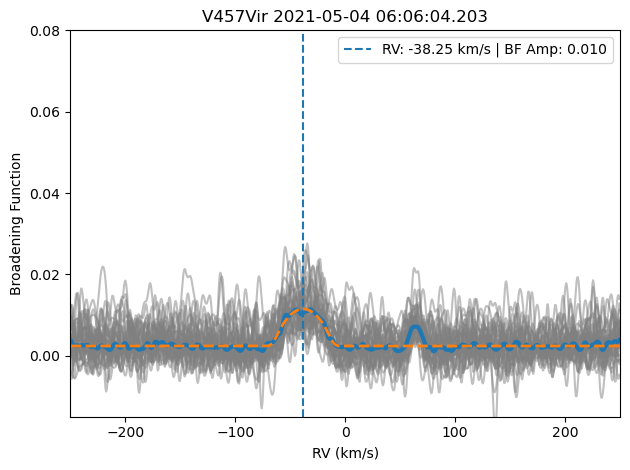


End
 ------------------------------------------------------------


In [8]:
SB1_indexes, SB2_indexes = [], []
results = []


p0s = []
for k in range(len(txtfiles)):
    print("File", k+1)
    filename = txtfiles[k]    #re-initialize a new filename
    filepath= os.path.join(path,filename)
    print(filepath)
    #read in the pickle and smooth the broadening function to instrumental resolution
    
    tar,tar_spec = pkl.load(open(filepath,'rb'))
    tar_spec = saph.bf.analysis(tar,tar_spec,R = R_coude)
    
    print(f'Number of Spectral Orders: {len(tar)}')

    ##############
    print(f"BJD: {BJD[k]}")
    print(f"BVCORR {BVCORR[k]}")
    time_title = Time(BJD[k], format='jd', scale='tdb')
    date_title = time_title.utc.iso
    # filesystem-safe date string
    #date_str = time_title.utc.strftime("%Y-%m-%d")
    # OR, if you want time resolution:
    date_str = time_title.utc.strftime("%Y-%m-%dT%H-%M-%S")

    
    # RV creation
    vel,bf,bf_sterr,bf_wstd = saph.bf.weight_combine(tar,tar_spec,vel_gt_lt=(+150,-150))
    ##############

    
    # plot everything
    #fig, ax = plt.subplots(figsize=(8,4))
    fig,ax = plt.subplots(1)
    for i in range(tar.size):
        ax.plot(tar_spec[tar[i]]['vel'],
                tar_spec[tar[i]]['bf_smooth'],
                color="grey", alpha=0.5)

    ax.plot(vel, bf, label="Observed", lw=3)

    # define colors: largest peak = red, second = green
    center_colors = ['red', 'green']
    width_alphas  = [0.5, 0.5]  # widths will be same color but semi‐transparent





    ax.set_title(f"{star} {date_title}")
    ax.set_xlabel('RV (km/s)')
    ax.set_ylabel('Broadening Function')
    #ax.axvline(rvsmean, ls='--')
    plt.xlim(-250, 250)
    plt.ylim(-0.015, 0.08)
    #ax.axhline(0.01, ls = '--')
    ax.axhline(0.0075, ls = '--', alpha = 0.75)
    plt.legend()

    from scipy.signal import find_peaks, peak_widths
    peaks, props = find_peaks(bf, prominence=0.00001, distance = 25, height = 0.005) #These values work for most systems, may have to adjust
    num_peaks = len(peaks)

    
    # Isolate the two highest‐amplitude peaks
    peak_heights = bf[peaks]
    n_to_plot    = min(num_peaks, 2)
    top_idxs     = np.argsort(peak_heights)[::-1][:n_to_plot]
    two_peaks    = peaks[top_idxs]

    # get half‐max widths for those peaks
    widths, height_at_half, left_ips, right_ips = peak_widths(bf, two_peaks, rel_height=0.5)
    if num_peaks == 0:
        print("  no peaks found")
        plt.show()
        continue

    
        
    for i, peak in enumerate(two_peaks):
        c = center_colors[i]
        # 1) vertical line at the peak center
        ax.axvline(vel[peak], ls="--", color=c)
    
        # 2) left/right velocities for half‐max
        v_low  = np.interp(left_ips[i],  np.arange(len(vel)), vel)
        v_high = np.interp(right_ips[i], np.arange(len(vel)), vel)
    
        # 3) horizontal half‐max line
        ax.hlines(y=height_at_half[i],
                  xmin=v_low, xmax=v_high,
                  colors=c, linestyles='--', alpha=0.7)
    
        # 4a) tiny vertical bars at the two ends:
        #ax.plot([v_low, v_high],
        #        [height_at_half[i], height_at_half[i]],
        #        marker='|', linestyle='', markersize=10, color=c)
    
        # 4b) simple dots instead:
        ax.scatter([v_low, v_high],
                    [height_at_half[i]]*2,
                    marker='o', s = 10, color=c, zorder = 10)
        print(f"  Peak {i+1}: center = {vel[peak]:.2f} km/s, width = {(v_high - v_low):.2f} km/s")

    plt.tight_layout()
    plt.show()
    plt.close()



    from Fit_SB1 import Run_SB1
    from Fit_SB2 import Run_SB2
    

    if num_peaks < 2 or Force_SB1 == True or widths[1] < 5:
        print("SB1")
        SB1_indexes.append(k)

        idx = np.arange(len(vel))
        left_vels  = np.interp(left_ips,  idx, vel)
        right_vels = np.interp(right_ips, idx, vel)
        # now pull out the three vectors:
        peak_amps   = bf[two_peaks]               # amplitudes at the two peaks
        peak_rvs    = vel[two_peaks]              # RV centerlines
        peak_widths = right_vels - left_vels      # width (km/s)
        
        print("Amps:",   peak_amps)
        print("Centers:",peak_rvs)
        print("Widths:", peak_widths)

        if manual == True:
            p0 = guesses[k]
        else:
            p0 = [peak_amps[0]*1.1, peak_rvs[0]*1.1, peak_widths[0]*1.1/2,
              0.0]
        
        print(f"p0: {[round(x, 3) for x in p0]}")
        output = Run_SB1(tar,tar_spec, vel,bf,bf_sterr,bf_wstd, 
                filename, star, date_title, BVCORR[k], p0)
        results.append((BJD[k], *output))
        print([output])





    
    else:
        print("SB2")
        SB2_indexes.append(k)

        idx = np.arange(len(vel))
        left_vels  = np.interp(left_ips,  idx, vel)
        right_vels = np.interp(right_ips, idx, vel)
        # now pull out the three vectors:
        peak_amps   = bf[two_peaks]               # amplitudes at the two peaks
        peak_rvs    = vel[two_peaks]              # RV centerlines
        peak_widths = right_vels - left_vels      # width (km/s)
        
        print("Amps:",   peak_amps)
        print("Centers:",peak_rvs)
        print("Widths:", peak_widths)

        if manual == True:
            p0 = guesses[k]
        #elif k == len(txtfiles) - 1:
        #    p0 = [ 0.014269385896399384, -74.66480800670901, 13.186207343707627, 0.015669322856370602, 68.224514112524, 33.489414447793436, 0.0001]
        else:
            p0 = [peak_amps[0]*1.1, peak_rvs[0]*1.1, peak_widths[0]*1.1/2,
             peak_amps[1]*1.075, peak_rvs[1]*1.05, peak_widths[1]*1.05/2,
              0.0]
        print(f"p0: {[round(x, 3) for x in p0]}")
        output = Run_SB2(tar,tar_spec, vel,bf,bf_sterr,bf_wstd, 
                        filename, star, date_title, BVCORR[k], p0)
        results.append((BJD[k], *output))
        print(output)

    #if k == 2:
    #    plt.savefig(f"{star}_{k}", dpi = 300)


    plt.tight_layout()
    
    outfile = outdir / f"{star}_{date_str}.png"
    plt.savefig(outfile, dpi=150, bbox_inches="tight")   #Save BF profiles
    
    plt.show()
    plt.close()

    p0s.append(p0)     




    
    print()

print("End\n" , "--"*30)


In [9]:
print("p0 guesses:")   #prints all p0 guesses for review, can copy this for redoing manual guessing per-iteration
for p0 in p0s:
    print(f"{[round(x, 3) for x in p0]},")

p0 guesses:
[0.012, -12.008, 22.386, 0.0],
[0.012, -6.578, 22.763, 0.0],
[0.013, 14.249, 22.335, 0.0],
[0.012, 41.794, 22.951, 0.0],
[0.012, -11.585, 22.48, 0.0],
[0.013, -38.253, 22.507, 0.0],


In [10]:
print("BJD | RV1 | RV1_hi | RV1_lo | Vsini1 | Vsini1_err | RV2 | RV2_hi | RV2_lo | Vsini2 | Vsini2_err")
print("--"*45)


for i, tup in enumerate(results):
    formatted = ", ".join(f"{x:.4f}" for x in tup)
    if i < len(results) - 1:
        print(f"[{formatted}],")
    else:
        print(f"[{formatted}]")


BJD | RV1 | RV1_hi | RV1_lo | Vsini1 | Vsini1_err | RV2 | RV2_hi | RV2_lo | Vsini2 | Vsini2_err
------------------------------------------------------------------------------------------
[2458980.7383, -28.9859, 0.2224, 0.1819, 26.0696, 0.2970, nan, nan, nan, nan, nan],
[2459245.9470, 19.4141, 0.1515, 0.1475, 26.4476, 0.3335, nan, nan, nan, nan, nan],
[2459303.7377, 16.9929, 0.1328, 0.1327, 26.1713, 0.3381, nan, nan, nan, nan, nan],
[2459305.7878, 43.3995, 0.2020, 0.1659, 26.6591, 0.3339, nan, nan, nan, nan, nan],
[2459327.6926, -20.5231, 0.2800, 0.2494, 26.5571, 0.3269, nan, nan, nan, nan, nan],
[2459338.7550, -52.2968, 0.3821, 0.4483, 26.9664, 0.3817, nan, nan, nan, nan, nan]


Primary
  Semi-Amplitude  : 47.848 km/s
  Mean            : -3.667 km/s
  STD             : 32.825 km/s
Primary Error Bars
  RV1_hi max      : 0.382 km/s
  RV1_hi mean     : 0.228 km/s
  RV1_lo max      : 0.448 km/s
  RV1_lo mean     : 0.221 km/s

Vsini1
  Mean            : 26.479
  Error mean      : 0.335
  Error max       : 0.382

Secondary RV2 is all NaN; skipping its stats, Vsini2, and plot.


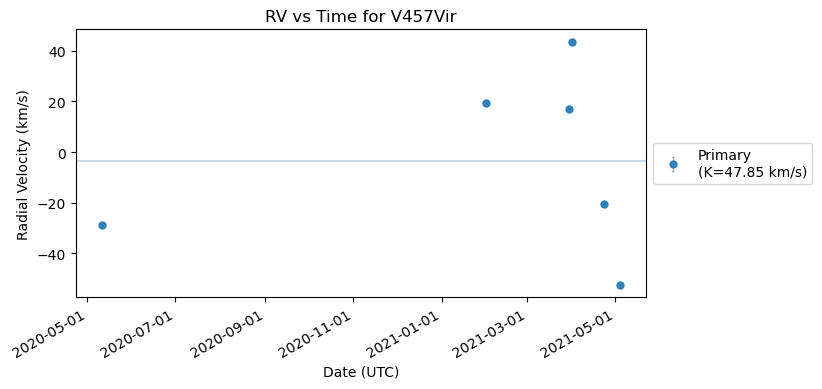

Number of files used: 6


In [17]:

#re-import in case we want to manually run results, for example:
#results = np.array([
#        [RV data format from {starname}_RV.txt],
#        [RV data format from {starname}_RV.txt],
#])

#Also, see example at the bottom of this file for UCAC2 28842571

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.time import Time


#=========================================================
#RV, Vsini stats and plot for this star

# setup array/data tables
data     = np.array(results)
bjd      = data[:,0]
rv1      = data[:,1]
rv1_hi   = data[:,2]
rv1_lo   = data[:,3]
vsini1   = data[:,4]
vsini1_er= data[:,5]
rv2      = data[:,6]
rv2_hi   = data[:,7]
rv2_lo   = data[:,8]
vsini2   = data[:,9]
vsini2_er= data[:,10]

# PRIMARY RV stats
primary_amp    = (np.nanmax(rv1) - np.nanmin(rv1)) / 2
primary_mean   = np.nanmean(rv1)
primary_std    = np.nanstd(rv1)
rv1_hi_max     = np.nanmax(rv1_hi)
rv1_hi_mean    = np.nanmean(rv1_hi)
rv1_lo_max     = np.nanmax(rv1_lo)
rv1_lo_mean    = np.nanmean(rv1_lo)

print(f"""Primary
  Semi-Amplitude  : {primary_amp:.3f} km/s
  Mean            : {primary_mean:.3f} km/s
  STD             : {primary_std:.3f} km/s
Primary Error Bars
  RV1_hi max      : {rv1_hi_max:.3f} km/s
  RV1_hi mean     : {rv1_hi_mean:.3f} km/s
  RV1_lo max      : {rv1_lo_max:.3f} km/s
  RV1_lo mean     : {rv1_lo_mean:.3f} km/s
""")

# Vsini1 stats
vs1_mean      = np.nanmean(vsini1)
vs1_err_mean  = np.nanmean(vsini1_er)
vs1_err_max   = np.nanmax(vsini1_er)
print(f"""Vsini1
  Mean            : {vs1_mean:.3f}
  Error mean      : {vs1_err_mean:.3f}
  Error max       : {vs1_err_max:.3f}
""")

# Mask for valid secondary points
mask2 = ~np.isnan(rv2)

# Convert BJD → datetime
t     = Time(bjd, format='jd', scale='tdb')
dates = t.to_datetime()

fig, ax = plt.subplots(figsize=(7,4))

# Plot primary
ax.errorbar(dates, rv1,
            yerr=[rv1_lo, rv1_hi],
            fmt='o',
            label=f"Primary\n(K={primary_amp:.2f} km/s)",
            ecolor='grey', capsize=1, elinewidth=0.5,
            ms=5, alpha=0.9)

# Plot + compute secondary if we have any real points
if mask2.any():
    rv2_v      = rv2[mask2]
    rv2_lo_v   = rv2_lo[mask2]
    rv2_hi_v   = rv2_hi[mask2]
    dates_v    = dates[mask2]

    secondary_amp   = (np.nanmax(rv2_v) - np.nanmin(rv2_v)) / 2
    secondary_mean  = np.nanmean(rv2_v)
    secondary_std   = np.nanstd(rv2_v)
    rv2_hi_max      = np.nanmax(rv2_hi_v)
    rv2_hi_mean     = np.nanmean(rv2_hi_v)
    rv2_lo_max      = np.nanmax(rv2_lo_v)
    rv2_lo_mean     = np.nanmean(rv2_lo_v)

    print(f"""Secondary
  Semi-Amplitude  : {secondary_amp:.3f} km/s
  Mean            : {secondary_mean:.3f} km/s
  STD             : {secondary_std:.3f} km/s
Secondary Error Bars
  RV2_hi max      : {rv2_hi_max:.3f} km/s
  RV2_hi mean     : {rv2_hi_mean:.3f} km/s
  RV2_lo max      : {rv2_lo_max:.3f} km/s
  RV2_lo mean     : {rv2_lo_mean:.3f} km/s
""")

    # Vsini2 stats
    vs2 = vsini2[mask2]
    vs2_er = vsini2_er[mask2]
    vs2_mean     = np.nanmean(vs2)
    vs2_err_mean = np.nanmean(vs2_er)
    vs2_err_max  = np.nanmax(vs2_er)
    print(f"""Vsini2
  Mean            : {vs2_mean:.3f}
  Error mean      : {vs2_err_mean:.3f}
  Error max       : {vs2_err_max:.3f}
""")

    ax.errorbar(dates_v, rv2_v,
                yerr=[rv2_lo_v, rv2_hi_v],
                fmt='x',
                label=f"Secondary\n(K={secondary_amp:.2f} km/s)",
                ecolor='grey', capsize=1, elinewidth=0.5,
                ms=5, alpha=0.9)
    ax.axhline(secondary_mean, alpha=0.25, color='orange')
else:
    print("Secondary RV2 is all NaN; skipping its stats, Vsini2, and plot.")

# primary mean line
ax.axhline(primary_mean, alpha=0.25)

# y‐axis padding
if mask2.any():
    y_min = min(np.nanmin(rv1), np.nanmin(rv2)) - 5
    y_max = max(np.nanmax(rv1), np.nanmax(rv2)) + 5
else:
    y_min = np.min(rv1) - 5
    y_max = np.max(rv1) + 5
ax.set_ylim(y_min, y_max)

# date formatting
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()

ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Radial Velocity (km/s)')
ax.set_title('RV vs Time for ' + star)

# legend outside
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.75, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()

# ensure output folder & save
outdir = "PNGs"
os.makedirs(outdir, exist_ok=True)
plt.savefig(f"{outdir}/{star}.png", dpi=135, bbox_inches='tight')   #uncomment this to save the file
plt.show()
print(f"Number of files used: {len(data)}")

In [15]:
#Save data to .txt file formats:



# 0) number of data points
n_points = len(data)

# 1) Build the summary row
row = [
    star,
    n_points,                                    # number of points
    primary_amp,                                 # RV1_amp
    rv1_hi_max,                                  # rv1_hi
    rv1_lo_max,                                  # rv1_lo
    (secondary_amp  if mask2.any() else np.nan), # RV2_amp
    (rv2_hi_max     if mask2.any() else np.nan), # rv2_hi
    (rv2_lo_max     if mask2.any() else np.nan), # rv2_lo
]

# 2) Update the global summary file in array form
summary_dir  = "summary"
summary_file = os.path.join(summary_dir, "results_summary.txt")
os.makedirs(summary_dir, exist_ok=True)

# Read lines
entries = {}
if os.path.exists(summary_file):
    with open(summary_file, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("Star,"):
                continue
            # line looks like: ['StarName', N, ...],
            first = line.split(",", 2)[0]           # "['StarName'"
            key   = first.lstrip("[").strip().strip("'\"")
            entries[key] = line.rstrip(",")

# Build this star's line
sec_amp_str = f"{secondary_amp:.3f}" if mask2.any() else "nan"
sec_hi_str  = f"{rv2_hi_max:.3f}"    if mask2.any() else "nan"
sec_lo_str  = f"{rv2_lo_max:.3f}"    if mask2.any() else "nan"

row_str = "['%s', %d, %.3f, %.3f, %.3f, %s, %s, %s]," % (
    star,
    n_points,
    primary_amp,
    rv1_hi_max,
    rv1_lo_max,
    sec_amp_str,
    sec_hi_str,
    sec_lo_str
)
entries[star] = row_str

# Write back sorted by star name, with header
with open(summary_file, "w") as f:
    f.write("Star, N, RV1_amp, rv1_hi, rv1_lo, RV2_amp, rv2_hi, rv2_lo\n")
    for name in sorted(entries):
        f.write(entries[name] + "\n")


# 3) Write the detailed per-star file
star_dir = os.path.join("starstxt4", star)
os.makedirs(star_dir, exist_ok=True)
star_file = os.path.join(star_dir, f"{star}.txt")
star_data = os.path.join(star_dir, f"{star}_RVs.txt")

with open(star_file, "w") as f:
    f.write(f"Star: {star}\n")
    f.write(f"Data length: {n_points}\n\n")

    # Primary
    f.write("Primary\n")
    f.write(f"  Amplitude       : {primary_amp:.3f} km/s\n")
    f.write(f"  Mean            : {primary_mean:.3f} km/s\n")
    f.write(f"  STD             : {primary_std:.3f} km/s\n")
    f.write("Primary Error Bars\n")
    f.write(f"  RV1_hi max      : {rv1_hi_max:.3f} km/s\n")
    f.write(f"  RV1_hi mean     : {rv1_hi_mean:.3f} km/s\n")
    f.write(f"  RV1_lo max      : {rv1_lo_max:.3f} km/s\n")
    f.write(f"  RV1_lo mean     : {rv1_lo_mean:.3f} km/s\n\n")

    # Vsini1
    f.write("Vsini1\n")
    f.write(f"  Mean            : {vs1_mean:.3f}\n")
    f.write(f"  Error mean      : {vs1_err_mean:.3f}\n")
    f.write(f"  Error max       : {vs1_err_max:.3f}\n\n")


    
    # Secondary (if present)
    if mask2.any():
        f.write("Secondary\n")
        f.write(f"  Amplitude       : {secondary_amp:.3f} km/s\n")
        f.write(f"  Mean            : {secondary_mean:.3f} km/s\n")
        f.write(f"  STD             : {secondary_std:.3f} km/s\n")
        f.write("Secondary Error Bars\n")
        f.write(f"  RV2_hi max      : {rv2_hi_max:.3f} km/s\n")
        f.write(f"  RV2_hi mean     : {rv2_hi_mean:.3f} km/s\n")
        f.write(f"  RV2_lo max      : {rv2_lo_max:.3f} km/s\n")
        f.write(f"  RV2_lo mean     : {rv2_lo_mean:.3f} km/s\n\n")
        f.write("Vsini2\n")
        f.write(f"  Mean            : {vs2_mean:.3f}\n")
        f.write(f"  Error mean      : {vs2_err_mean:.3f}\n")
        f.write(f"  Error max       : {vs2_err_max:.3f}\n")
    else:
        f.write("Secondary RV2 is all NaN; skipping its stats and Vsini2.\n\n")
        
    f.write("\nInitial Fit Parameters (p0):\n")
    for p0 in p0s:
        f.write(f"{[round(x, 3) for x in p0]}\n")



with open(star_data, "w") as f:
    for j in range(n_points):
            bjds     = bjd[j]
            rv1s      = rv1[j]
            rv1_his   = rv1_hi[j]
            rv1_los   = rv1_lo[j]
    
            if mask2.any():
                rv2s     = rv2[j]
                rv2_his  = rv2_hi[j]
                rv2_los  = rv2_lo[j]
                line = f"[{bjds:.5f}, {rv1s:.3f}, {rv1_his:.3f}, {rv1_los:.3f}, {rv2s:.3f}, {rv2_his:.3f}, {rv2_los:.3f}]"
            else:
                line = f"[{bjds:.5f}, {rv1s:.3f}, {rv1_his:.3f}, {rv1_los:.3f}, nan, nan, nan]"

            if j < n_points-1:
                f.write(line + ',\n')

            else:
                f.write(line + '\n')



# manually eliminate vsini data if necessary
bad_indices = [] #modify this by index

for k in bad_indices:
    vsini1[k]    = np.nan
    vsini1_er[k] = np.nan
    if mask2.any():
        vsini2[k]    = np.nan
        vsini2_er[k] = np.nan



# New file: per-epoch Vsini data
vsini_file = os.path.join(star_dir, f"{star}_vsini.txt")

with open(vsini_file, "w") as f:
    for j in range(n_points):
        bjds   = bjd[j]
        vs1    = vsini1[j]
        vs1_er = vsini1_er[j]

        # Apply cutoff for primary
        if vs1_er > 5:
            vs1    = np.nan
            vs1_er = np.nan

        if mask2.any():
            vs2    = vsini2[j]
            vs2_er = vsini2_er[j]

            # Apply cutoff for secondary
            if vs2_er > 5:
                vs2    = np.nan
                vs2_er = np.nan

            line = (
                f"[{bjds:.5f}, "
                f"{vs1:.3f}, {vs1_er:.3f}, "
                f"{vs2:.3f}, {vs2_er:.3f}]"
            )
        else:
            line = (
                f"[{bjds:.5f}, "
                f"{vs1:.3f}, {vs1_er:.3f}, "
                f"nan, nan]"
            )

        if j < n_points - 1:
            f.write(line + ",\n")
        else:
            f.write(line + "\n")

print("========== End of Line =========")

========== End of Line =========


In [702]:
#Manual results adjustments
#UCAC2 28842571 example, which required manual rearranging of BF peak 1 and peak 2 identification
results = [
[2459067.9228, 1.7543, 0.0695, 0.0671, 8.6124, 0.1027, -40.6678, 0.0989, 0.0797, 7.8151, 0.0789],
[2459095.8570, 39.9079, 0.0857, 0.0952, 7.8699, 0.0824, -78.4719, 0.0701, 0.0614, 8.4064, 0.0910],
[2459095.8756, 39.9900, 0.0889, 0.0882, 8.0521, np.nan, -78.5009, 0.0532, 0.0593, -0.0043, np.nan],
[2459095.8942, 40.0078, 0.0900, 0.0854, 8.3663, 0.0982, -78.4602, 0.0478, 0.0473, 7.7398, 0.0633],
[2459108.7816, -16.3875, 0.7907, 18.5443, 7.8354, np.nan, 14.5437, 0.9062, 17.7271, 0.0631, np.nan],
[2459108.8008, -35.0916, 12.3175, 0.0825, 8.0105, 0.0639, -3.1322, 7.8485, 0.1059, 7.2037, 0.0854],
[2459119.7984, -51.2200, 0.0935, 0.0880, 8.6194, 0.0642, 12.2430, 0.0718, 0.0784, 7.4499, 0.1003],
[2459119.8170, -51.1326, 0.0909, 0.0788, 8.4906, 0.1901, 12.2563, 0.0682, 0.0602, 0.1289, 533514.2332],
[2459119.8357, -51.0890, 0.0830, 0.0708, 7.5252, 1204265.9514, 12.2673, 0.0733, 0.0931, 0.3079, 0.2523],
[2459121.7752, -46.2364, 0.1040, 0.1221, 8.4845, 0.0958, 6.6792, 0.0772, 0.0736, 7.2751, 0.0727],
[2459121.7937, 6.7237, 0.0829, 0.0892, 8.6546, 0.1284, -46.0700, 0.0904, 0.1186, 7.0430, 0.0994],
[2459121.8125, 6.6914, 0.0798, 0.0909, 8.6059, 1591643.5713, -46.0196, 0.1162, 0.1092, 0.4013, 0.1693],
[2459122.8305, -40.4786, 0.0829, 0.0807, 0.1945, 919637.1632, 1.8984, 0.0551, 0.0522, 0.2392, 1468262.3134],
[2459122.8512, 1.0896, 0.1362, 0.1170, 8.3489, 0.1015, -40.5417, 0.1824, 0.1534, 7.3713, 0.1675],
[2459122.8734, -40.1044, 0.0877, 0.0928, 8.1991, 0.0830, 1.7327, 0.0724, 0.0653, 7.3824, 0.1015],
[2459123.8009, -15.4522, 0.6137, 5.9529, 6.3253, 1923631.1952, 11.4557, 0.6001, 7.7655, 0.4102, 0.2585],
[2459123.8195, -15.3954, 0.6367, 5.7852, 8.0240, 0.0679, 11.3285, 0.4547, 6.5179, 6.5076, 0.0751],
[2459123.8381, -15.0156, 0.5222, 4.4648, 6.4502, 2401974.6218, 11.5851, 0.4234, 6.2783, 0.4570, 0.2546],
[2459124.8030, -19.2934, 0.0785, 0.0724, 11.2697, 0.0760, np.nan, np.nan, np.nan, np.nan, np.nan],
[2459124.8227, -19.2935, 0.1001, 0.0931, 10.8481, 0.0837, np.nan, np.nan, np.nan, np.nan, np.nan],
[2459124.8413, -19.3516, 0.0753, 0.0781, 10.4838, 0.0602, np.nan, np.nan, np.nan, np.nan, np.nan],
[2459174.6834, -27.1278, 0.0682, 0.0707, 8.8877, 0.1983, -11.0049, 0.0848, 0.0872, 0.2702, 1045756.3653],
[2459174.7043, -27.1435, 0.0665, 0.0597, 10.5609, 0.1349, -10.8599, 0.0793, 0.0813, 0.4029, 585814.5243],
[2459174.7244, -27.4205, 0.0583, 0.0590, 9.0498, 0.1602, -10.8339, 0.0615, 0.0669, 0.3893, 954004.3598],
[2459175.6527, -30.7817, 0.1365, 0.1112, 8.0480, np.nan, -6.2118, 0.1816, 0.1294, -0.0264, np.nan],
[2459175.6711, -31.0169, 0.1259, 0.1022, 0.4544, 2004788.1763, -6.3709, 0.1770, 0.1227, 7.5350, 0.3208],
[2459175.6896, -31.3187, 0.1527, 0.1094, 0.4198, 1629143.6102, -6.4406, 0.2508, 0.1651, 7.5049, 0.2932],
[2459187.6342, -50.5727, 0.2106, 0.2108, 0.2120, 863831.9351, 13.1717, 0.1446, 0.1551, -7.2928, 0.3300],
[2459187.6529, 13.1248, 0.1391, 0.1345, 8.5213, 0.0750, -50.6065, 0.2075, 0.1982, 7.4366, 0.1291],
[2459187.6714, 13.0292, 0.1325, 0.1462, 8.5234, 1637551.6367, -50.4906, 0.1532, 0.1722, 0.5119, 0.2254],
[2459188.6361, -48.3751, 0.0846, 0.0923, 0.4474, 2501451.4716, 11.0379, 0.0909, 0.0958, 0.4811, 2345496.2292],
[2459188.6546, -48.4029, 0.0777, 0.0579, 7.7629, 908425.2109, 10.8411, 0.1036, 0.0938, 0.6214, 0.3059],
[2459452.9127, -48.9548, 0.0844, 0.0676, 8.0859, 0.1949, 10.1398, 0.1114, 0.1061, 0.4351, 2541674.0596],
[2459453.8904, -50.5279, 0.0857, 0.0898, 8.3627, 0.0680, 11.4890, 0.0828, 0.0918, 7.8815, 0.1064],
[2459490.8374, 13.8370, 0.0705, 0.0622, 8.6215, 0.0627, -52.5073, 0.0931, 0.0854, 7.6702, 0.0719]
]

In [708]:
results = np.array(results)
np.mean(results[:,2]), np.mean(results[:,3])

(0.5086542857142856, 1.0746571428571425)